In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci
import matplotlib.pyplot as plt

from libdet import Hamiltonian
from detnqs.model import Backflow
from detnqs.vstate import MCState
from detnqs.sampler.mcmc import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import adamsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("double")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

def plot_convergence(history, e_fci):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    step = np.arange(len(history))

    ax = axes[0]
    ax.plot(step, history, linewidth=1.4)
    ax.axhline(e_fci, linestyle="--", linewidth=1.2)
    ax.set_xlabel("Step")
    ax.set_ylabel("Energy (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    ax.semilogy(step, np.abs(np.asarray(history) - e_fci), linewidth=1.4)
    ax.set_xlabel("Step")
    ax.set_ylabel("|E - E_FCI| (Hartree)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    return fig, axes

In [2]:
mol = gto.M(
    # atom=
    # '''
    # N   0.00000000,  0.00000000,  0.0000000
    # N   2.50000000,  0.00000000,  0.0000000
    # ''',
    atom=
    '''
    O   0.00000000,  0.00000000,  0.00000000
    H   0.75700000,  0.00000000,  0.58590000
    H  -0.75700000,  0.00000000,  0.58590000
    ''',
    basis="6-31g",
    unit="Angstrom",
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Canonical MO
h1e = np.asarray(mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff, dtype=np.float64)
eri = np.asarray(ao2mo.restore(8, ao2mo.kernel(mol, mf.mo_coeff), norb), dtype=np.float64)

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

solver = fci.direct_spin0.FCI(mol)
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
s2, mult = fci.spin_op.spin_square(ci, norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
print(f"S^2  : {s2:.6f}")

model = Backflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,))

SCF energy : -75.983997609010
FCI energy : -76.120842435457
S^2  : 0.000000


step=   0  energy=-75.98396830  variance= 0.42733633  ess= 521.0  ess_unique= 1.000  acc=0.001  n_uniq=289.0  n_eval=35259.0
         times: backward= 0.0055 | forward= 0.0832 | graph= 0.1545 | reduction= 0.0111 | sampler= 0.0031 | total= 0.2576
step=  10  energy=-76.10209249  variance= 0.02657005  ess= 467.5  ess_unique= 1.016  acc=0.019  n_uniq=303.0  n_eval=43324.0
         times: backward= 0.0040 | forward= 0.1026 | graph= 0.1632 | reduction= 0.0090 | sampler= 0.0055 | total= 0.2844
step=  20  energy=-76.11178649  variance= 0.01025377  ess= 447.5  ess_unique= 1.019  acc=0.038  n_uniq=343.0  n_eval=58868.0
         times: backward= 0.0039 | forward= 0.1339 | graph= 0.2126 | reduction= 0.0121 | sampler= 0.0039 | total= 0.3665
step=  30  energy=-76.11273517  variance= 0.01150830  ess= 390.4  ess_unique= 1.025  acc=0.044  n_uniq=396.0  n_eval=67345.0
         times: backward= 0.0045 | forward= 0.0804 | graph= 0.2536 | reduction= 0.0123 | sampler= 0.0075 | total= 0.3584
step=  40  energ

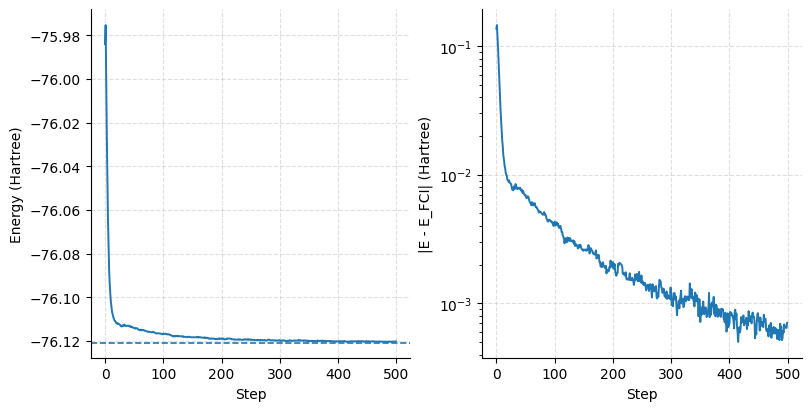

In [4]:
sampler = MCSampler(
    n_sample=1024,
    n_chain=1024,
    n_discard=1024,
    alpha=1.0,
    proposal="ham",
    blur=0.5,
    blur_kernel="ham",
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init="hf",
    key=jax.random.key(0),
)

optimizer = optax.chain(
    adamsr(shift=1e-2),
    optax.scale(-5e-2)
)

vmc = VMC.init(state, optimizer)

history = []
steps = 500

for step in range(steps):
    stats = vmc.step()
    history.append(stats['energy'])

    if step % 10 == 0 or step == steps - 1:
        print(
            f"step={step:4d}  "
            f"energy={history[-1]: .8f}  "
            f"variance={stats['variance']: .8f}  "
            f"ess={stats['ess']: .1f}  "
            f"ess_unique={stats['ess_unique']: .3f}  "
            f"acc={stats['accept']:.3f}  "
            f"n_uniq={stats['n_unique']:}  "
            f"n_eval={stats['n_eval']:}"
        )

        time_items = sorted(
            (k[5:], float(stats[k])) for k in stats if k.startswith("time_")
        )
        if time_items:
            line = " | ".join(f"{name}= {val:.4f}" for name, val in time_items)
            print(f"         times: " + line)

plot_convergence(history, e_fci)
plt.show()